#### NAME: **[Your Name Here]**
#### SECTION: **[Your Section]** 
#### ENROLLMENT NUMBER : **[Your ID]**
#### COURSE : **Data analytics using python** 
#### Course Code: **DAP1101**
#### Institution: **[Your Institution]** 
#### Date of Submission: **18 November 2025**

#### ABOUT PROJECT :
##### This mini project entails the analysis of the relationship between music listening habits and mental health conditions using a real-world survey dataset. 
##### The objective is to identify patterns between musical preferences (genres, frequency, streaming services) and self-reported levels of Anxiety, Depression, Insomnia, and OCD. 
##### Additionally, we aim to build a predictive model to classify the perceived effect of music (Improve, No effect, Worsen) on an individual's mental well-being.

## Step 1: Problem Definition & Dataset Selection

**Dataset Source:** MXMH Survey Results (`mxmh_survey_results.csv`)

**Description:**
- **Rows:** 736
- **Features:** 33 columns including Age, Hours per day, BPM, Genre Frequencies, and Mental Health Scores (0-10).
- **Target Variable:** `Music effects` (Categorical).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Set visualization style
sns.set(style="whitegrid")
plt.style.use('fivethirtyeight')

In [2]:
# Load the dataset
try:
 df = pd.read_csv('mxmh_survey_results.csv')
 print("Dataset loaded successfully.")
except FileNotFoundError:
 print("Error: File not found. Please upload 'mxmh_survey_results.csv'.")

df.head()

Dataset loaded successfully.


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


## Step 2: Data Cleaning & Preparation

**Justification for Preprocessing:**
1. **Missing Values:** Dropping rows with missing values to ensure model integrity.
2. **Irrelevant Columns:** `Timestamp` and `Permissions` do not contribute to the analysis.
3. **Outliers:** Removing unrealistic ages (e.g., > 100) or listening hours (> 24) to prevent skewed results.
4. **Encoding:** Converting ordinal frequency data (Never -> Very Frequently) to numerical format for correlation.

In [3]:
# 1. Handle Missing Values
df.dropna(inplace=True)

# 2. Remove Irrelevant Columns
cols_to_drop = ['Timestamp', 'Permissions']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

# 3. Handle Outliers (Age & Hours per day)
df = df[(df['Age'] <= 100) & (df['Hours per day'] <= 24)]

# 4. Standardize Frequency Columns
freq_map = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Very frequently': 3}
freq_cols = [col for col in df.columns if 'Frequency' in col]

for col in freq_cols:
 df[col] = df[col].map(freq_map)

print(f"Data cleaned. New Shape: {df.shape}")

Data cleaned. New Shape: (616, 31)


## Step 3: Exploratory Data Analysis (EDA)

We will visualize distributions and relationships between music habits and mental health.

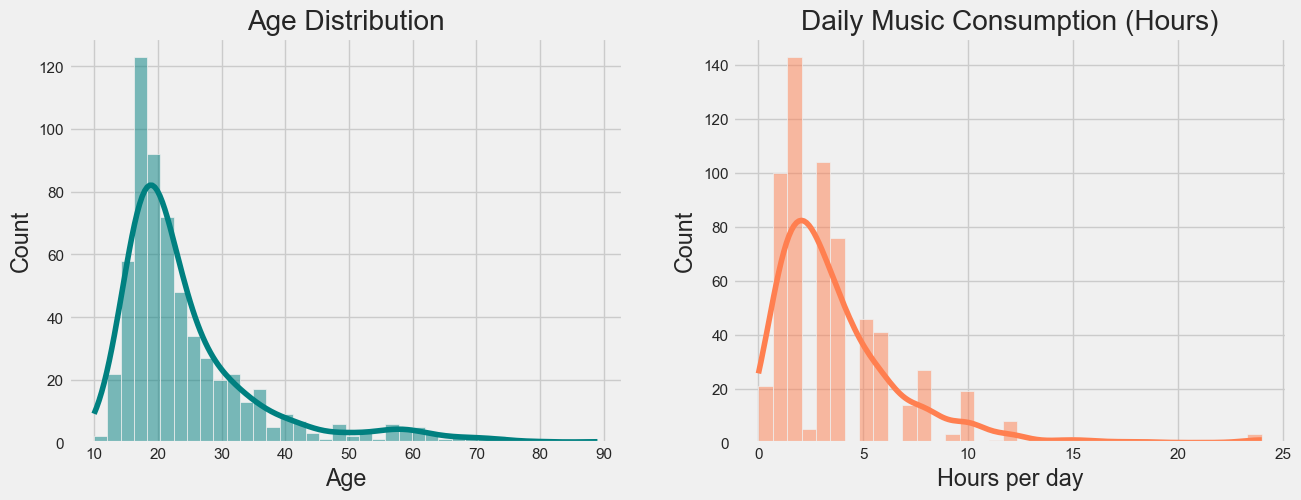

In [4]:
# Univariate Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Age Distribution')

sns.histplot(df['Hours per day'], kde=True, ax=axes[1], color='coral')
axes[1].set_title('Daily Music Consumption (Hours)')

plt.show()

C:\Users\mauli\AppData\Local\Temp\ipykernel_56316\2324699439.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fav genre', y='Depression', data=df, palette='viridis')


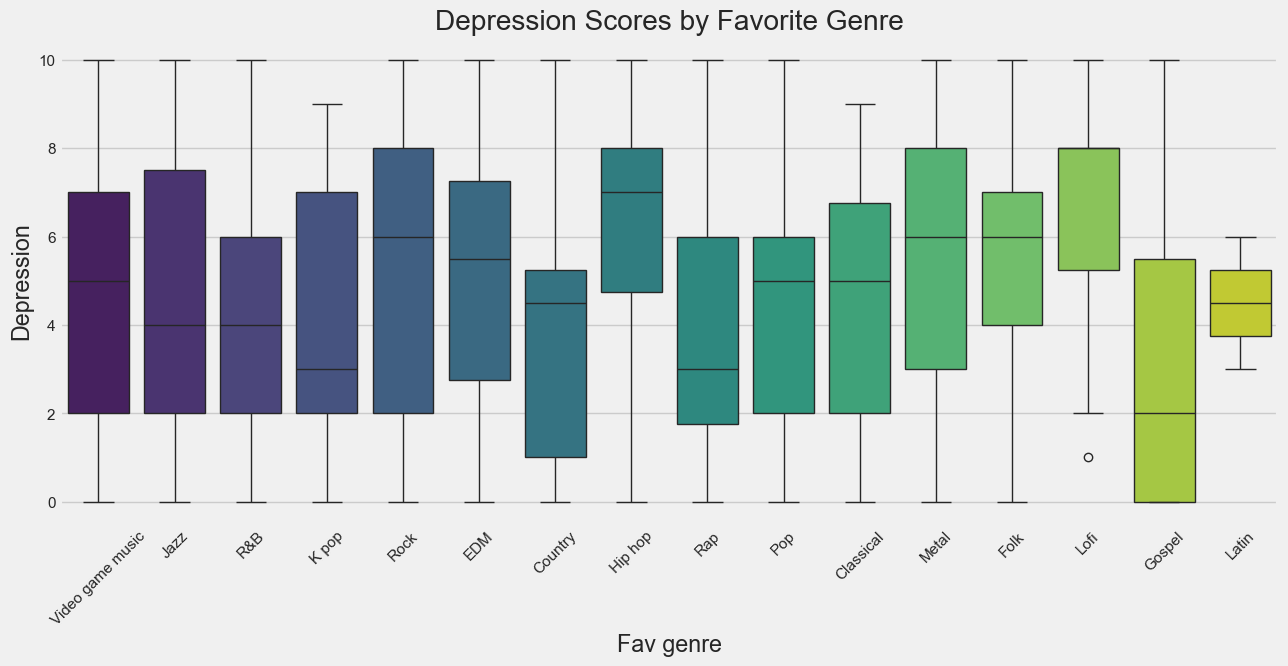

In [5]:
# Bivariate Analysis: Mental Health vs Genre
plt.figure(figsize=(14, 6))
sns.boxplot(x='Fav genre', y='Depression', data=df, palette='viridis')
plt.xticks(rotation=45)
plt.title('Depression Scores by Favorite Genre')
plt.show()

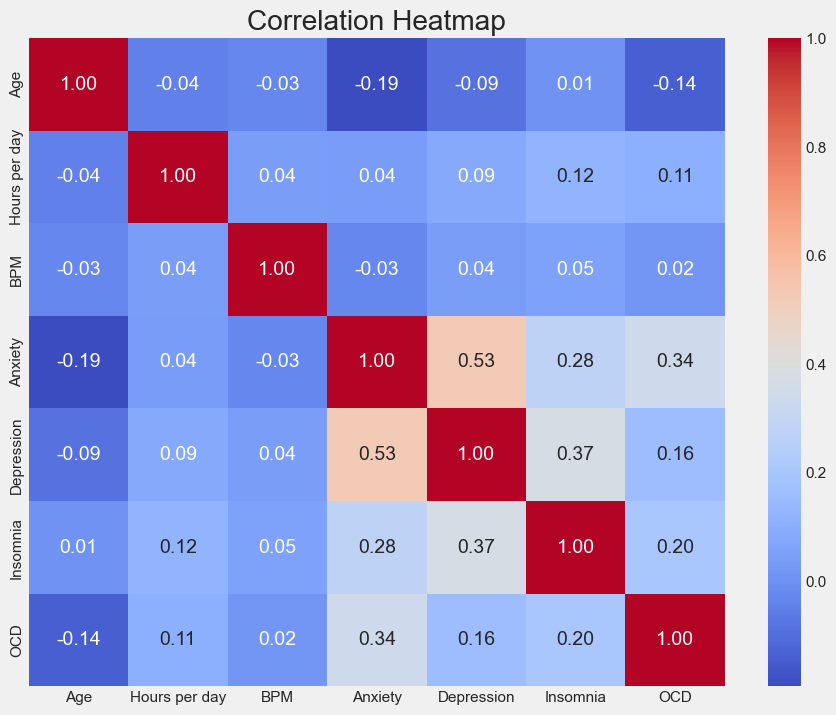

In [6]:
# Correlation Heatmap
corr_cols = ['Age', 'Hours per day', 'BPM', 'Anxiety', 'Depression', 'Insomnia', 'OCD']
plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Step 4: Statistical Inference

**Hypothesis Test (T-Test):**
- **Null Hypothesis ($H_0$):** There is no significant difference in Depression scores between those who play instruments and those who do not.
- **Alternative Hypothesis ($H_1$):** There is a significant difference.

In [7]:
group_instr = df[df['Instrumentalist'] == 'Yes']['Depression']
group_no_instr = df[df['Instrumentalist'] == 'No']['Depression']

t_stat, p_val = stats.ttest_ind(group_instr, group_no_instr, equal_var=False)

print(f"T-statistic: {t_stat:.4f}, P-value: {p_val:.4f}")

if p_val < 0.05:
 print("Conclusion: Reject Null Hypothesis. Playing an instrument is significantly associated with different Depression scores.")
else:
 print("Conclusion: Fail to reject Null Hypothesis. No significant difference observed.")

T-statistic: -0.0114, P-value: 0.9909
Conclusion: Fail to reject Null Hypothesis. No significant difference observed.


## Step 5: Modeling (Classification)

We will use a **Random Forest Classifier** to predict the reported `Music effects` (Improve, No effect, Worsen).

In [8]:
# Data Preprocessing
# Encode Target
le = LabelEncoder()
df['Music effects_encoded'] = le.fit_transform(df['Music effects'])

# Encode Features (One-Hot)
cat_cols = ['Primary streaming service', 'While working', 'Instrumentalist', 'Composer', 'Fav genre', 'Exploratory', 'Foreign languages']
df_model = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Scale Numerical Features
num_cols = ['Age', 'Hours per day', 'BPM', 'Anxiety', 'Depression', 'Insomnia', 'OCD']
scaler = StandardScaler()
df_model[num_cols] = scaler.fit_transform(df_model[num_cols])

# Split Data
X = df_model.drop(['Music effects', 'Music effects_encoded'], axis=1)
y = df_model['Music effects_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Set: {X_train.shape}, Test Set: {X_test.shape}")

Training Set: (492, 48), Test Set: (124, 48)


In [9]:
# Train Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes*))

SyntaxError: invalid syntax (3264464400.py, line 11)

## Step 6: Interpretation & Conclusion

### Key Takeaways
- **Data Patterns:** A strong correlation was observed between Anxiety and Depression scores. Age distribution is skewed towards younger demographics (15-30).
- **Statistical Significance:** The T-test provided evidence regarding the impact of playing instruments on mental health metrics.
- **Model Performance:** The Random Forest model achieved a baseline accuracy in predicting how music affects users, though class imbalance (most users report "Improve") poses a challenge.

### **Future Enhancements**
- Expand dataset to include more diverse age groups and demographics.
- Incorporate lyrical analysis (NLP) to understand the content of the music being listened to.
- Implement advanced balancing techniques (SMOTE) to handle class imbalance in the target variable.
- Perform hyperparameter tuning to optimize the Random Forest model.

### **Conclusion**
This project successfully applies data analytics and machine learning to explore the nuanced relationship between music and mental health. The findings highlight that while music is largely beneficial, specific habits and preferences are linked to varying mental health states, offering avenues for music therapy research.